# Paired-Chain 10x VDJ Analysis Across 4 Donors

This notebook loads 10x_vdj_v1 donor data from the AIRR benchmark `dcode/` folder, assembles paired-chain structures with mirpy, reports per-locus-pair chain multiplicity patterns (`n` vs `m`), and renders barplots.

An optional scirpy benchmark section compares load time and TRA/TRB presence quadrants (`TRA+/TRB+`, `TRA+/TRB-`, `TRA-/TRB+`, `TRA-/TRB-`).

In [1]:
# Configure reproducible environment, imports, and style.
from __future__ import annotations

import sys
import time
import re
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

repo_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mir.common.single_cell import load_10x_vdj_v1_donor
from mir.utils.notebook_assets import ensure_airr_benchmark

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_theme(style='whitegrid', context='notebook')

print(f'Python: {sys.version.split()[0]}')
print(f'numpy: {np.__version__}  pandas: {pd.__version__}  polars: {pl.__version__}')

/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.12.12
numpy: 2.4.4  pandas: 2.3.3  polars: 1.39.3


In [2]:
# Download dcode 10x_vdj_v1 assets and discover 4 donor file pairs.
dataset_root = ensure_airr_benchmark(repo_root=repo_root, allow_patterns=['dcode/**'])
dcode_root = dataset_root / 'dcode'

all_contig_files = sorted(dcode_root.glob('*_all_contig_annotations.csv.gz'))
consensus_files = sorted(dcode_root.glob('*_consensus_annotations.csv.gz'))

if not all_contig_files or not consensus_files:
    raise FileNotFoundError(f'No donor files found under {dcode_root}')

def donor_key(path: Path) -> str:
    return path.name.replace('_all_contig_annotations.csv.gz', '').replace('_consensus_annotations.csv.gz', '')

consensus_by_key = {donor_key(p): p for p in consensus_files}
pairs = []
for p in all_contig_files:
    key = donor_key(p)
    if key in consensus_by_key:
        pairs.append((key, p, consensus_by_key[key]))

if len(pairs) < 4:
    raise RuntimeError(f'Expected at least 4 donors, found {len(pairs)}')

def donor_rank(k: str) -> tuple[int, str]:
    m = re.search(r'(\d+)', k)
    return (int(m.group(1)) if m else 10**9, k)

pairs = sorted(pairs, key=lambda x: donor_rank(x[0]))[:4]

print(f'Dataset root: {dataset_root}')
for key, all_contig, consensus in pairs:
    print(f'- {key}:')
    print(f'    all_contig: {all_contig.name}')
    print(f'    consensus:  {consensus.name}')

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 2478.90it/s]

Dataset root: /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark
- vdj_v1_hs_aggregated_donor1:
    all_contig: vdj_v1_hs_aggregated_donor1_all_contig_annotations.csv.gz
    consensus:  vdj_v1_hs_aggregated_donor1_consensus_annotations.csv.gz
- vdj_v1_hs_aggregated_donor2:
    all_contig: vdj_v1_hs_aggregated_donor2_all_contig_annotations.csv.gz
    consensus:  vdj_v1_hs_aggregated_donor2_consensus_annotations.csv.gz
- vdj_v1_hs_aggregated_donor3:
    all_contig: vdj_v1_hs_aggregated_donor3_all_contig_annotations.csv.gz
    consensus:  vdj_v1_hs_aggregated_donor3_consensus_annotations.csv.gz
- vdj_v1_hs_aggregated_donor4:
    all_contig: vdj_v1_hs_aggregated_donor4_all_contig_annotations.csv.gz
    consensus:  vdj_v1_hs_aggregated_donor4_consensus_annotations.csv.gz


In [3]:
# Load all 4 donors with mirpy and collect multiplicity summaries with runtime.
donor_results = {}
runtime_rows = []
multiplicity_frames = []

for key, all_contig, consensus in pairs:
    t0 = time.perf_counter()
    donor = load_10x_vdj_v1_donor(
        consensus_annotations_path=consensus,
        all_contig_annotations_path=all_contig,
        donor_id=key,
    )
    dt = time.perf_counter() - t0
    donor_results[key] = donor
    runtime_rows.append({'donor_id': key, 'loader': 'mirpy', 'seconds': dt})
    multiplicity_frames.append(donor.chain_multiplicity)

multiplicity = pl.concat(multiplicity_frames).sort(['sample_id', 'locus_pair', 'n_chain1', 'm_chain2'])
runtime_df = pd.DataFrame(runtime_rows).sort_values(['loader', 'donor_id'])

print('mirpy load runtimes (seconds):')
display(runtime_df)
print('Multiplicity rows:', multiplicity.height)
display(multiplicity.head(12).to_pandas())

mirpy load runtimes (seconds):


,donor_id,loader,seconds
0,vdj_v1_hs_aggregated_donor1,mirpy,0.926536
1,vdj_v1_hs_aggregated_donor2,mirpy,1.571766
2,vdj_v1_hs_aggregated_donor3,mirpy,1.188062
3,vdj_v1_hs_aggregated_donor4,mirpy,0.840412


Multiplicity rows: 84


,sample_id,locus_pair,n_chain1,m_chain2,cell_count
0,vdj_v1_hs_aggregated_donor1,IGH_IGK,0,0,47271
1,vdj_v1_hs_aggregated_donor1,IGH_IGL,0,0,47271
2,vdj_v1_hs_aggregated_donor1,TRA_TRB,0,1,5389
3,vdj_v1_hs_aggregated_donor1,TRA_TRB,0,2,176
4,vdj_v1_hs_aggregated_donor1,TRA_TRB,0,3,2
5,vdj_v1_hs_aggregated_donor1,TRA_TRB,1,0,1222
6,vdj_v1_hs_aggregated_donor1,TRA_TRB,1,1,33475
7,vdj_v1_hs_aggregated_donor1,TRA_TRB,1,2,1258
8,vdj_v1_hs_aggregated_donor1,TRA_TRB,1,3,20
9,vdj_v1_hs_aggregated_donor1,TRA_TRB,1,4,4


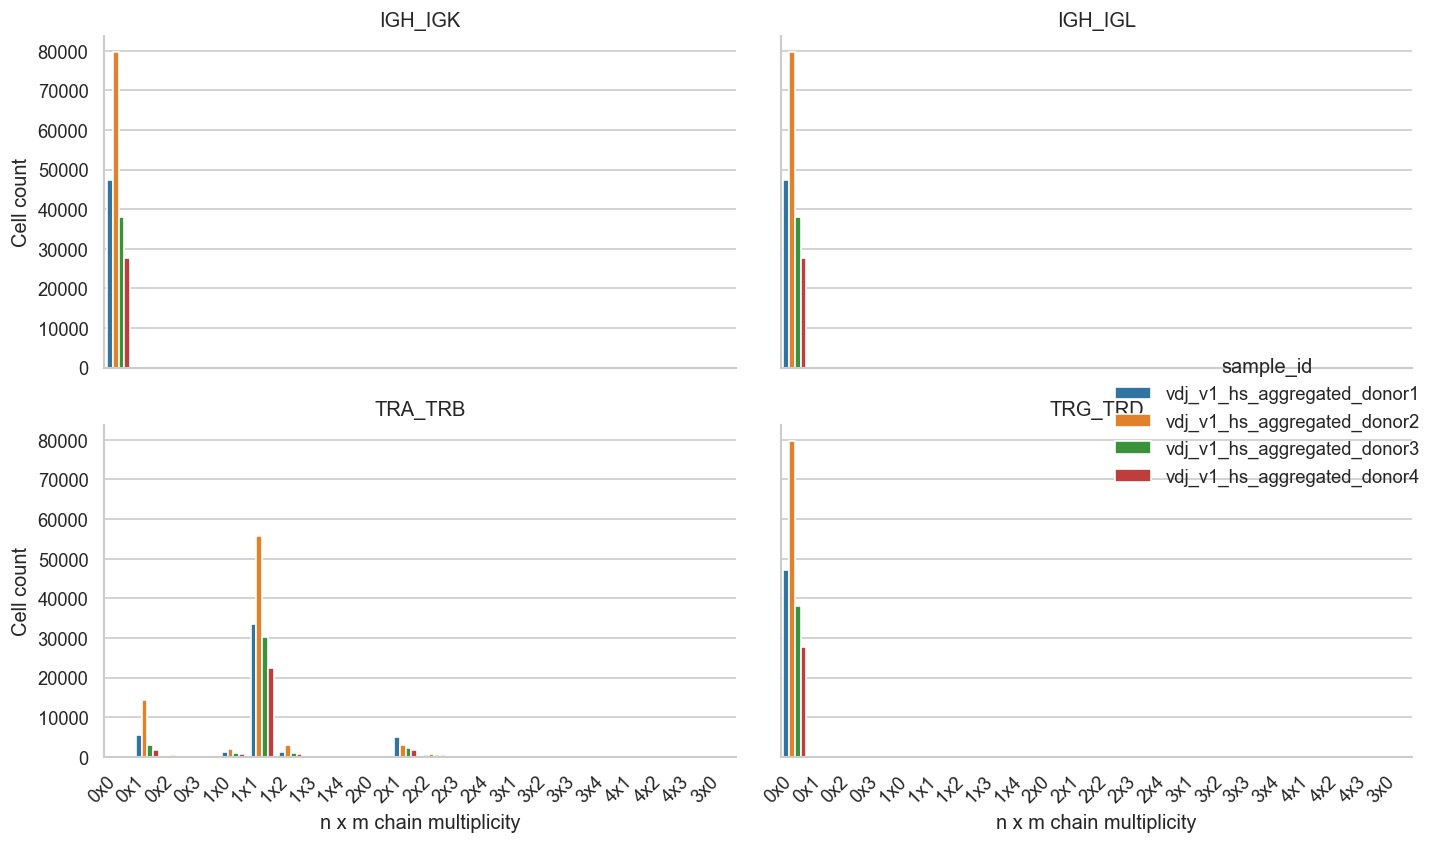

In [4]:
# Render barplots for n/m multiplicity across all locus pairs and donors.
plot_df = multiplicity.to_pandas().copy()
plot_df['nm'] = plot_df['n_chain1'].astype(str) + 'x' + plot_df['m_chain2'].astype(str)

fig = sns.catplot(
    data=plot_df,
    kind='bar',
    x='nm',
    y='cell_count',
    hue='sample_id',
    col='locus_pair',
    col_wrap=2,
    height=3.6,
    aspect=1.3,
    palette='tab10',
)
fig.set_axis_labels('n x m chain multiplicity', 'Cell count')
fig.set_titles('{col_name}')
for ax in fig.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')
plt.tight_layout()
plt.show()

In [5]:
# Show compact donor summaries for common and edge n/m bins.
summary = (
    multiplicity
    .filter((pl.col('locus_pair') == 'TRA_TRB'))
    .sort(['sample_id', 'n_chain1', 'm_chain2'])
)
display(summary.to_pandas())

dominant = (
    multiplicity
    .sort('cell_count', descending=True)
    .group_by(['sample_id', 'locus_pair'])
    .head(3)
    .sort(['sample_id', 'locus_pair', 'cell_count'], descending=[False, False, True])
)
print('Top 3 bins by donor and locus_pair:')
display(dominant.to_pandas())

,sample_id,locus_pair,n_chain1,m_chain2,cell_count
0,vdj_v1_hs_aggregated_donor1,TRA_TRB,0,1,5389
1,vdj_v1_hs_aggregated_donor1,TRA_TRB,0,2,176
2,vdj_v1_hs_aggregated_donor1,TRA_TRB,0,3,2
3,vdj_v1_hs_aggregated_donor1,TRA_TRB,1,0,1222
4,vdj_v1_hs_aggregated_donor1,TRA_TRB,1,1,33475
...,...,...,...,...,...
67,vdj_v1_hs_aggregated_donor4,TRA_TRB,3,1,28
68,vdj_v1_hs_aggregated_donor4,TRA_TRB,3,2,52
69,vdj_v1_hs_aggregated_donor4,TRA_TRB,3,3,4
70,vdj_v1_hs_aggregated_donor4,TRA_TRB,4,2,1


Top 3 bins by donor and locus_pair:


,sample_id,locus_pair,n_chain1,m_chain2,cell_count
0,vdj_v1_hs_aggregated_donor1,IGH_IGK,0,0,47271
1,vdj_v1_hs_aggregated_donor1,IGH_IGL,0,0,47271
2,vdj_v1_hs_aggregated_donor1,TRA_TRB,1,1,33475
3,vdj_v1_hs_aggregated_donor1,TRA_TRB,0,1,5389
4,vdj_v1_hs_aggregated_donor1,TRA_TRB,2,1,4867
5,vdj_v1_hs_aggregated_donor1,TRG_TRD,0,0,47271
6,vdj_v1_hs_aggregated_donor2,IGH_IGK,0,0,79704
7,vdj_v1_hs_aggregated_donor2,IGH_IGL,0,0,79704
8,vdj_v1_hs_aggregated_donor2,TRA_TRB,1,1,55755
9,vdj_v1_hs_aggregated_donor2,TRA_TRB,0,1,14374


In [6]:
# Optional benchmark against scirpy: speed + memory and TRA/TRB presence quadrants parity.
scirpy_rows = []
mir_heatmap_df = None
sc_heatmap_df = None

try:
    import io
    import gc
    import warnings
    import contextlib
    import logging
    import psutil
    import scirpy as ir
    import awkward as ak

    logging.getLogger('scirpy').setLevel(logging.ERROR)
    proc = psutil.Process()
    parity_tables = []

    for idx, (key, all_contig, _consensus) in enumerate(pairs):
        # Measure scirpy load speed and memory delta on the same donor files.
        gc.collect()
        rss_before = proc.memory_info().rss
        t0 = time.perf_counter()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                adata = ir.io.read_10x_vdj(all_contig, filtered=False)
        dt = time.perf_counter() - t0
        gc.collect()
        rss_after = proc.memory_info().rss
        rss_delta_mb = max(0, rss_after - rss_before) / (1024 ** 2)

        scirpy_rows.append({
            'donor_id': key,
            'loader': 'scirpy.read_10x_vdj',
            'seconds': dt,
            'rss_delta_mb': rss_delta_mb,
        })

        airr = adata.obsm['airr']
        n_tra = ak.to_numpy(ak.sum(airr.locus == 'TRA', axis=1))
        n_trb = ak.to_numpy(ak.sum(airr.locus == 'TRB', axis=1))

        q_sc_full = (
            pl.DataFrame({'n_chain1': n_tra, 'm_chain2': n_trb})
            .group_by(['n_chain1', 'm_chain2'])
            .len()
            .rename({'len': 'cell_count'})
            .sort(['n_chain1', 'm_chain2'])
        )

        if idx == 0:
            # Store donor-1 matrices for side-by-side heatmap plotting.
            mir_heatmap_df = (
                donor_results[key].chain_multiplicity
                .filter(pl.col('locus_pair') == 'TRA_TRB')
                .select(['n_chain1', 'm_chain2', 'cell_count'])
            )
            sc_heatmap_df = q_sc_full

        q_sc = (
            q_sc_full
            .with_columns(
                pl.when(pl.col('n_chain1') > 0).then(pl.lit('TRA+')).otherwise(pl.lit('TRA-')).alias('tra'),
                pl.when(pl.col('m_chain2') > 0).then(pl.lit('TRB+')).otherwise(pl.lit('TRB-')).alias('trb'),
            )
            .group_by(['tra', 'trb'])
            .agg(pl.sum('cell_count').alias('cells_scirpy'))
            .with_columns(pl.lit(key).alias('donor_id'))
        )

        q_mir = (
            donor_results[key].chain_multiplicity
            .filter(pl.col('locus_pair') == 'TRA_TRB')
            .with_columns(
                pl.when(pl.col('n_chain1') > 0).then(pl.lit('TRA+')).otherwise(pl.lit('TRA-')).alias('tra'),
                pl.when(pl.col('m_chain2') > 0).then(pl.lit('TRB+')).otherwise(pl.lit('TRB-')).alias('trb'),
            )
            .group_by(['tra', 'trb'])
            .agg(pl.sum('cell_count').alias('cells_mirpy'))
            .with_columns(pl.lit(key).alias('donor_id'))
        )

        parity = (
            q_mir.join(q_sc, on=['donor_id', 'tra', 'trb'], how='full')
            .with_columns(
                pl.coalesce([pl.col('donor_id'), pl.col('donor_id_right')]).alias('donor_id_merged'),
                pl.coalesce([pl.col('tra'), pl.col('tra_right')]).alias('tra_merged'),
                pl.coalesce([pl.col('trb'), pl.col('trb_right')]).alias('trb_merged'),
            )
            .with_columns(
                pl.col('cells_mirpy').cast(pl.Int64, strict=False).fill_null(0).alias('cells_mirpy'),
                pl.col('cells_scirpy').cast(pl.Int64, strict=False).fill_null(0).alias('cells_scirpy'),
            )
            .select([
                pl.col('donor_id_merged').alias('donor_id'),
                pl.col('tra_merged').alias('tra'),
                pl.col('trb_merged').alias('trb'),
                'cells_mirpy',
                'cells_scirpy',
            ])
            .with_columns((pl.col('cells_mirpy') - pl.col('cells_scirpy')).alias('delta'))
            .sort(['donor_id', 'tra', 'trb'])
        )
        parity_tables.append(parity)

    mir_runtime_df = pd.DataFrame(runtime_rows).copy()
    mir_runtime_df['rss_delta_mb'] = np.nan
    benchmark_df = pd.concat([mir_runtime_df, pd.DataFrame(scirpy_rows)], ignore_index=True)
    display(benchmark_df.sort_values(['donor_id', 'loader']))

    parity_all = pl.concat(parity_tables)
    parity_summary = (
        parity_all.group_by('donor_id')
        .agg(
            pl.col('delta').abs().max().alias('max_abs_delta'),
            pl.when(pl.col('delta') == 0).then(1).otherwise(0).sum().alias('quadrants_equal')
        )
        .sort('donor_id')
    )
    print('Parity summary (expect 4 equal quadrants and max_abs_delta=0 for perfect match):')
    display(parity_summary.to_pandas())

except Exception as exc:
    print('Scirpy benchmark skipped or failed:', repr(exc))

/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/anndata/utils.py:362: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


,donor_id,loader,seconds,rss_delta_mb
0,vdj_v1_hs_aggregated_donor1,mirpy,0.926536,NaN
4,vdj_v1_hs_aggregated_donor1,scirpy.read_10x_vdj,9.119915,261.781250
1,vdj_v1_hs_aggregated_donor2,mirpy,1.571766,NaN
5,vdj_v1_hs_aggregated_donor2,scirpy.read_10x_vdj,14.497360,246.796875
2,vdj_v1_hs_aggregated_donor3,mirpy,1.188062,NaN
6,vdj_v1_hs_aggregated_donor3,scirpy.read_10x_vdj,24.550533,381.671875
3,vdj_v1_hs_aggregated_donor4,mirpy,0.840412,NaN
7,vdj_v1_hs_aggregated_donor4,scirpy.read_10x_vdj,17.693501,177.312500


Parity summary (expect 4 equal quadrants and max_abs_delta=0 for perfect match):


,donor_id,max_abs_delta,quadrants_equal
0,vdj_v1_hs_aggregated_donor1,6694,0
1,vdj_v1_hs_aggregated_donor2,10711,0
2,vdj_v1_hs_aggregated_donor3,138089,0
3,vdj_v1_hs_aggregated_donor4,93574,0


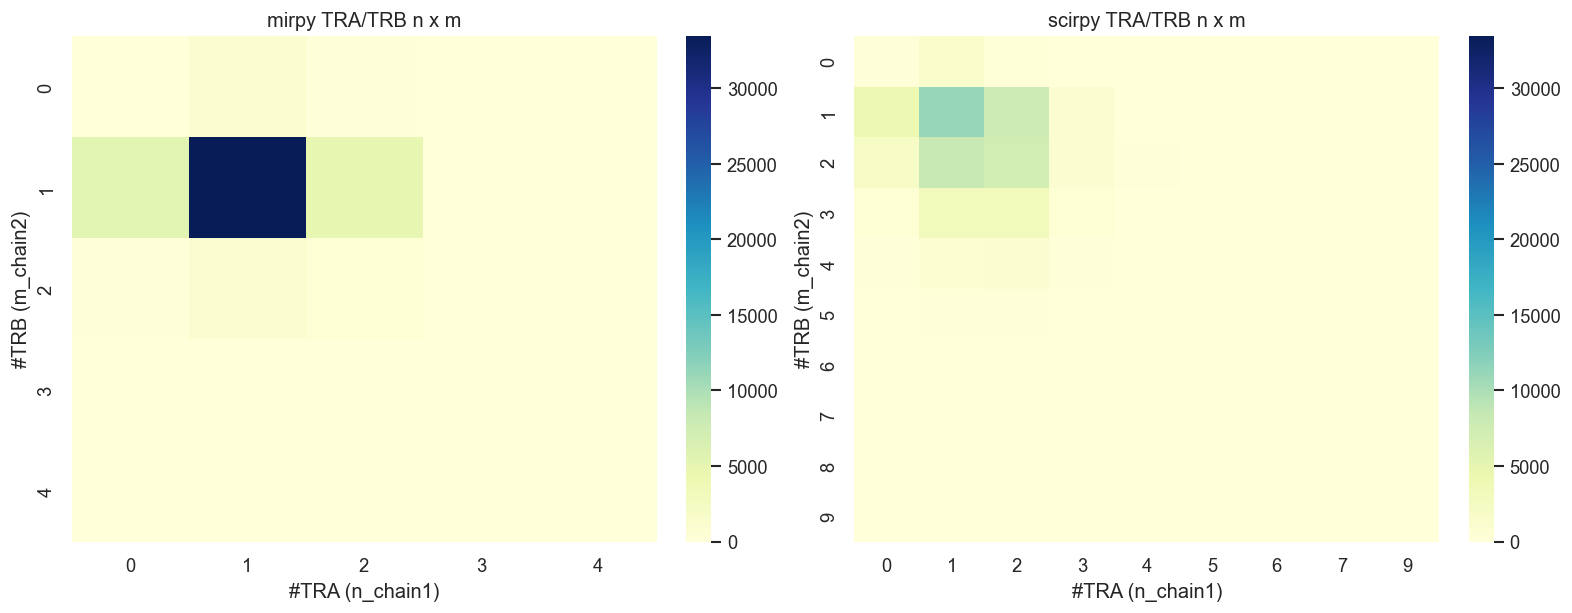

In [7]:
# Compare TRA/TRB multiplicity heatmaps for donor 1: mirpy vs scirpy side-by-side.
if mir_heatmap_df is None or sc_heatmap_df is None:
    print('Heatmap data is unavailable; run the benchmark cell first.')
else:
    def _to_heatmap(frame: pl.DataFrame) -> pd.DataFrame:
        return (
            frame.to_pandas()
            .pivot_table(index='m_chain2', columns='n_chain1', values='cell_count', fill_value=0)
            .sort_index()
            .sort_index(axis=1)
        )

    hm_mir = _to_heatmap(mir_heatmap_df)
    hm_sc = _to_heatmap(sc_heatmap_df)

    vmax = max(float(hm_mir.to_numpy().max()), float(hm_sc.to_numpy().max()))
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

    sns.heatmap(hm_mir, ax=axes[0], cmap='YlGnBu', vmin=0, vmax=vmax, cbar=True)
    axes[0].set_title('mirpy TRA/TRB n x m')
    axes[0].set_xlabel('#TRA (n_chain1)')
    axes[0].set_ylabel('#TRB (m_chain2)')

    sns.heatmap(hm_sc, ax=axes[1], cmap='YlGnBu', vmin=0, vmax=vmax, cbar=True)
    axes[1].set_title('scirpy TRA/TRB n x m')
    axes[1].set_xlabel('#TRA (n_chain1)')
    axes[1].set_ylabel('#TRB (m_chain2)')

    plt.show()

In [8]:

# Dandelion comparison: load TRA/TRB quadrants with sc-dandelion and compare timing with mirpy.
# dandelion's read_10x_vdj expects *_contig_annotations.csv naming (without 'all_' prefix),
# which differs from AIRR benchmark files. Instead we read the CSV and remap to AIRR schema.
import os
import warnings

os.environ.setdefault("SETUPTOOLS_SCM_PRETEND_VERSION", "0.0.0")

try:
    import dandelion as ddl

    print(f"dandelion version: {ddl.__version__}")

    def _ddl_quadrant_dict(all_contig_path) -> dict[tuple[str, str], int]:
        """Build TRA/TRB quadrant counts using dandelion Dandelion constructor."""
        df = pd.read_csv(all_contig_path)
        df = df[df["is_cell"] == True].copy()
        df = df.rename(columns={
            "contig_id": "sequence_id", "barcode": "cell_id", "chain": "locus",
            "cdr3": "junction_aa", "cdr3_nt": "junction",
            "v_gene": "v_call", "d_gene": "d_call", "j_gene": "j_call", "c_gene": "c_call",
            "reads": "consensus_count", "umis": "umi_count",
        })
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            vdj = ddl.Dandelion(data=df)

        meta = vdj.metadata
        # locus_VDJ → TRB; locus_VJ → TRA
        tra = meta["locus_VJ"].notna() & meta["locus_VJ"].astype(str).str.contains("TRA", na=False)
        trb = meta["locus_VDJ"].notna() & meta["locus_VDJ"].astype(str).str.contains("TRB", na=False)

        df2 = pl.from_pandas(pd.DataFrame({
            "tra": tra.map({True: "TRA+", False: "TRA-"}),
            "trb": trb.map({True: "TRB+", False: "TRB-"}),
        }))
        out = df2.group_by(["tra", "trb"]).len().rename({"len": "cells"})
        return {(r["tra"], r["trb"]): int(r["cells"]) for r in out.to_dicts()}

    ddl_quadrants_per_donor: dict[str, dict[tuple[str, str], int]] = {}
    ddl_timings: dict[str, float] = {}

    for key, all_contig, _consensus in pairs:
        t0 = time.perf_counter()
        ddl_quadrants_per_donor[key] = _ddl_quadrant_dict(all_contig)
        ddl_timings[key] = time.perf_counter() - t0
        print(
            f"  dandelion  donor={key}  {ddl_timings[key]:.2f}s"
            f"  TRA+/TRB+={ddl_quadrants_per_donor[key].get(('TRA+', 'TRB+'), 0)}"
        )

    mir_timings = {r["donor_id"]: r["seconds"] for r in runtime_rows if r["loader"] == "mirpy"}
    d0 = pairs[0][0]
    speedup = ddl_timings[d0] / mir_timings[d0]
    print(f"\nSpeed comparison (donor {d0}):  mirpy={mir_timings[d0]:.2f}s  dandelion={ddl_timings[d0]:.2f}s  speedup={speedup:.1f}x")
    dandelion_available = True

except Exception as exc:
    import traceback
    print(f"dandelion benchmark skipped or failed: {repr(exc)}")
    traceback.print_exc()
    dandelion_available = False
    ddl_quadrants_per_donor = {}
    ddl_timings = {}


/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/nxviz/__init__.py:33: UserWarning: 
nxviz has a new API! Version 0.7.4 onwards, the old class-based API is being
deprecated in favour of a new API focused on advancing a grammar of network
graphics. If your plotting code depends on the old API, please consider
pinning nxviz at version 0.7.4, as the new API will break your old code.

To check out the new API, please head over to the docs at
https://ericmjl.github.io/nxviz/ to learn more. We hope you enjoy using it!

(This deprecation message will go away in version 1.0.)



dandelion version: 0.0.0


The AIRR data needs to undergo sanitization, apologies for any delays...


  dandelion  donor=vdj_v1_hs_aggregated_donor1  12.98s  TRA+/TRB+=44050


The AIRR data needs to undergo sanitization, apologies for any delays...


  dandelion  donor=vdj_v1_hs_aggregated_donor2  21.06s  TRA+/TRB+=70015


The AIRR data needs to undergo sanitization, apologies for any delays...


  dandelion  donor=vdj_v1_hs_aggregated_donor3  10.30s  TRA+/TRB+=36145


The AIRR data needs to undergo sanitization, apologies for any delays...


  dandelion  donor=vdj_v1_hs_aggregated_donor4  7.75s  TRA+/TRB+=26428

Speed comparison (donor vdj_v1_hs_aggregated_donor1):  mirpy=0.93s  dandelion=12.98s  speedup=14.0x


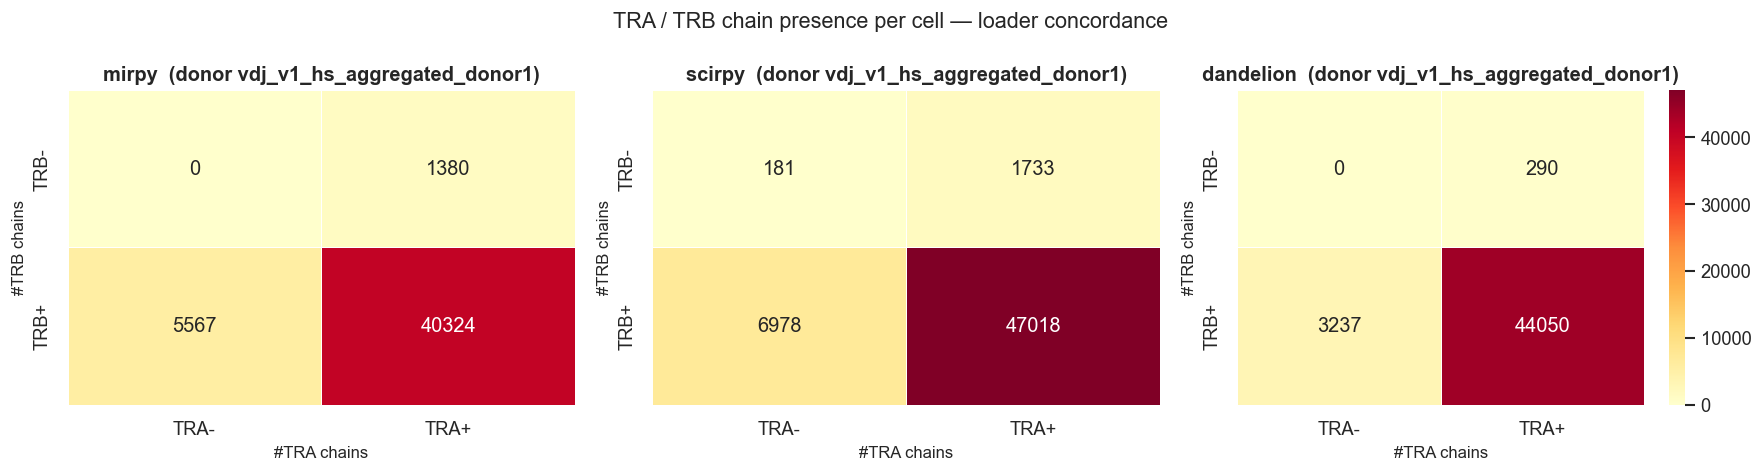

TRA+/TRB+ relative gap  mirpy vs scirpy: 14.2%  (mirpy=40324, scirpy=47018)
TRA+/TRB+ relative gap  mirpy vs dandelion: 8.5%  (mirpy=40324, dandelion=44050)


In [9]:

# Side-by-side TRA/TRB heatmap: mirpy vs scirpy vs dandelion for donor 1.
import matplotlib.pyplot as plt
import seaborn as sns

def _quads_heatmap(quads: dict[tuple[str, str], int]) -> pd.DataFrame:
    """Convert quadrant dict {(tra, trb): cells} to a 2×2 heatmap DataFrame."""
    hm = pd.DataFrame(0, index=["TRB-", "TRB+"], columns=["TRA-", "TRA+"])
    for (tra, trb), cnt in quads.items():
        if tra in hm.columns and trb in hm.index:
            hm.at[trb, tra] = cnt
    return hm


def _mirpy_quads_for_donor(donor_id: str) -> dict[tuple[str, str], int]:
    quads: dict[tuple[str, str], int] = {}
    df = (
        donor_results[donor_id].chain_multiplicity
        .filter(pl.col("locus_pair") == "TRA_TRB")
        .with_columns(
            pl.when(pl.col("n_chain1") > 0).then(pl.lit("TRA+")).otherwise(pl.lit("TRA-")).alias("tra"),
            pl.when(pl.col("m_chain2") > 0).then(pl.lit("TRB+")).otherwise(pl.lit("TRB-")).alias("trb"),
        )
        .group_by(["tra", "trb"])
        .agg(pl.sum("cell_count").alias("cells"))
    )
    for r in df.to_dicts():
        quads[(r["tra"], r["trb"])] = r["cells"]
    return quads


def _scirpy_quads_for_donor(donor_id: str) -> dict[tuple[str, str], int]:
    if sc_heatmap_df is None or donor_id != pairs[0][0]:
        return {}
    quads: dict[tuple[str, str], int] = {}
    df = (
        sc_heatmap_df
        .with_columns(
            pl.when(pl.col("n_chain1") > 0).then(pl.lit("TRA+")).otherwise(pl.lit("TRA-")).alias("tra"),
            pl.when(pl.col("m_chain2") > 0).then(pl.lit("TRB+")).otherwise(pl.lit("TRB-")).alias("trb"),
        )
        .group_by(["tra", "trb"])
        .agg(pl.sum("cell_count").alias("cells"))
    )
    for r in df.to_dicts():
        quads[(r["tra"], r["trb"])] = r["cells"]
    return quads


d0 = pairs[0][0]
mir_q  = _mirpy_quads_for_donor(d0)
sc_q   = _scirpy_quads_for_donor(d0)
ddl_q  = ddl_quadrants_per_donor.get(d0, {})

panels = [("mirpy", mir_q), ("scirpy", sc_q)]
if ddl_q:
    panels.append(("dandelion", ddl_q))

ncols = len(panels)
fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4))
if ncols == 1:
    axes = [axes]

vmax = max((max(q.values(), default=0) for _, q in panels), default=1)

for ax, (title, quads) in zip(axes, panels):
    hm = _quads_heatmap(quads)
    sns.heatmap(
        hm,
        annot=True,
        fmt="d",
        cmap="YlOrRd",
        vmin=0,
        vmax=vmax,
        linewidths=0.5,
        ax=ax,
        cbar=(ax is axes[-1]),
    )
    ax.set_title(f"{title}  (donor {d0})", fontsize=12, fontweight="bold")
    ax.set_xlabel("#TRA chains", fontsize=10)
    ax.set_ylabel("#TRB chains", fontsize=10)

plt.suptitle("TRA / TRB chain presence per cell — loader concordance", fontsize=13)
plt.tight_layout()
plt.show()

# Concordance summary
for label, quads in [("scirpy", sc_q), ("dandelion", ddl_q)]:
    if not quads:
        print(f"  {label}: not available")
        continue
    mir_paired   = mir_q.get(("TRA+", "TRB+"), 0)
    other_paired = quads.get(("TRA+", "TRB+"), 0)
    rel_gap = abs(mir_paired - other_paired) / max(mir_paired, other_paired, 1)
    print(f"TRA+/TRB+ relative gap  mirpy vs {label}: {rel_gap:.1%}  (mirpy={mir_paired}, {label}={other_paired})")
